In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

# Text processing
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Model building
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import roc_curve, auc

# Set random seeds for reproducibility
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)

print("✅ All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

✅ All libraries imported successfully!
TensorFlow version: 2.20.0
Pandas version: 2.3.3
NumPy version: 2.0.2


In [3]:
# Load the IMDB dataset
# Make sure the path is correct relative to your notebook location
df = pd.read_csv('./data/IMDB Dataset.csv')

print("✅ Dataset loaded successfully!")
print(f"\nDataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst 3 rows:")
df.head(3)

✅ Dataset loaded successfully!

Dataset shape: (50000, 2)
Columns: ['review', 'sentiment']

First 3 rows:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive


DATASET INFORMATION

Total reviews: 50000

Data types:
review       object
sentiment    object
dtype: object

Missing values:
review       0
sentiment    0
dtype: int64

Sentiment distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


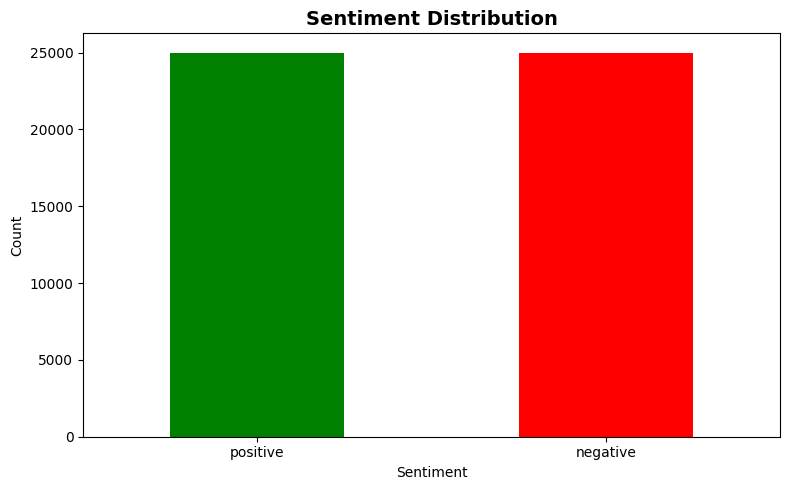


✅ Dataset is balanced!


In [4]:
print("="*60)
print("DATASET INFORMATION")
print("="*60)

print(f"\nTotal reviews: {len(df)}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nSentiment distribution:\n{df['sentiment'].value_counts()}")

# Visualize sentiment distribution
plt.figure(figsize=(8, 5))
df['sentiment'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Sentiment Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n✅ Dataset is balanced!" if df['sentiment'].value_counts()['positive'] == df['sentiment'].value_counts()['negative'] else "\n⚠️ Dataset is imbalanced!")

In [5]:
print("="*60)
print("SAMPLE REVIEWS")
print("="*60)

print("\n📗 POSITIVE REVIEW:")
print(df[df['sentiment'] == 'positive']['review'].iloc[0][:400] + "...")

print("\n📕 NEGATIVE REVIEW:")
print(df[df['sentiment'] == 'negative']['review'].iloc[0][:400] + "...")

SAMPLE REVIEWS

📗 POSITIVE REVIEW:
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to...

📕 NEGATIVE REVIEW:
Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zombie.<br /><br />OK, first of all when you're going to make a film you must Decide if its a thriller or a drama! As a drama the movie is watchable. Parents a...


REVIEW LENGTH STATISTICS
count    50000.000000
mean       231.156940
std        171.343997
min          4.000000
25%        126.000000
50%        173.000000
75%        280.000000
max       2470.000000
Name: review_length, dtype: float64


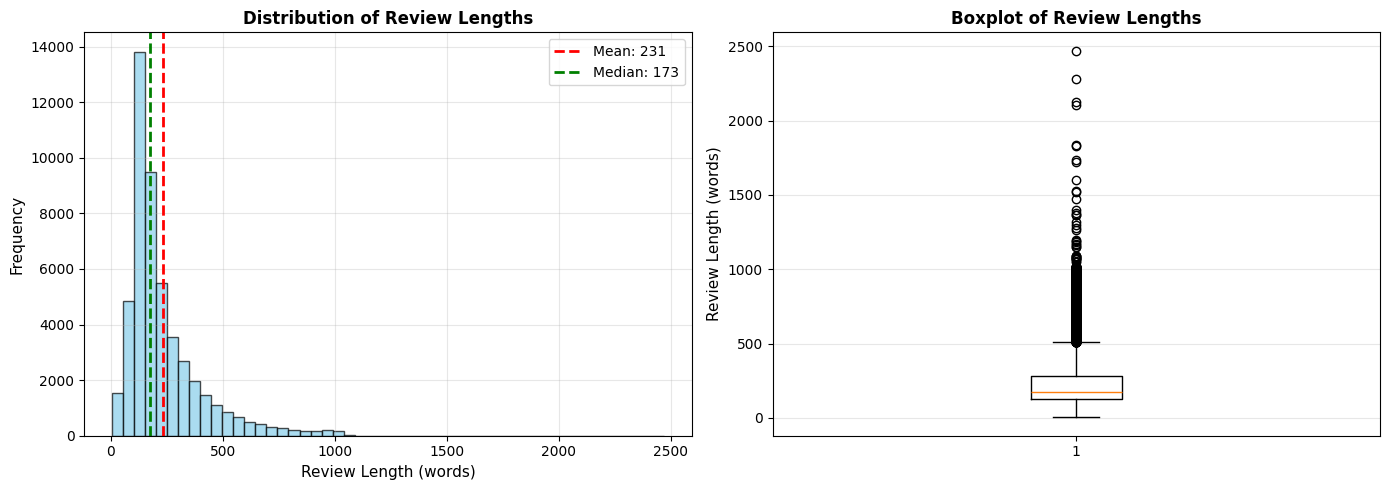


📊 We'll use MAX_LENGTH = 200 words
   This covers 59.1% of reviews


In [6]:
# Calculate review lengths
df['review_length'] = df['review'].apply(lambda x: len(x.split()))

print("="*60)
print("REVIEW LENGTH STATISTICS")
print("="*60)
print(df['review_length'].describe())

# Plot distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df['review_length'], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].set_xlabel('Review Length (words)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Distribution of Review Lengths', fontsize=12, fontweight='bold')
axes[0].axvline(df['review_length'].mean(), color='red', linestyle='--', 
                linewidth=2, label=f'Mean: {df["review_length"].mean():.0f}')
axes[0].axvline(df['review_length'].median(), color='green', linestyle='--', 
                linewidth=2, label=f'Median: {df["review_length"].median():.0f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Boxplot
axes[1].boxplot(df['review_length'], vert=True)
axes[1].set_ylabel('Review Length (words)', fontsize=11)
axes[1].set_title('Boxplot of Review Lengths', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\n📊 We'll use MAX_LENGTH = 200 words")
print(f"   This covers {(df['review_length'] <= 200).sum() / len(df) * 100:.1f}% of reviews")

In [7]:
import re

def clean_text(text):
    """
    Clean and preprocess text data
    """
    # Convert to lowercase
    text = text.lower()
    
    # Remove HTML tags
    text = re.sub(r'<[^>]+>', '', text)
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    
    # Remove special characters and digits (keep only letters and spaces)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # Remove extra whitespace
    text = ' '.join(text.split())
    
    return text

# Test the function with a sample
sample_text = "This movie is AMAZING!!! <br><br> Best film ever!!! 10/10 https://example.com"
print("="*70)
print("TEXT CLEANING TEST")
print("="*70)
print("\nOriginal text:")
print(f"  {sample_text}")
print("\nCleaned text:")
print(f"  {clean_text(sample_text)}")
print("\n✅ Text cleaning function defined successfully!")

TEXT CLEANING TEST

Original text:
  This movie is AMAZING!!! <br><br> Best film ever!!! 10/10 https://example.com

Cleaned text:
  this movie is amazing best film ever

✅ Text cleaning function defined successfully!


In [8]:
print("="*70)
print("CLEANING ALL REVIEWS")
print("="*70)
print("\n🧹 Cleaning in progress... This may take 1-2 minutes...")

df['review_clean'] = df['review'].apply(clean_text)

print("✅ Text cleaning completed!")
print(f"\nCleaned {len(df)} reviews")

# Show before and after example
print("\n" + "="*70)
print("BEFORE AND AFTER COMPARISON")
print("="*70)
sample_idx = 10

print("\n📄 ORIGINAL:")
print(df['review'].iloc[sample_idx][:300])

print("\n✨ CLEANED:")
print(df['review_clean'].iloc[sample_idx][:300])

CLEANING ALL REVIEWS

🧹 Cleaning in progress... This may take 1-2 minutes...
✅ Text cleaning completed!

Cleaned 50000 reviews

BEFORE AND AFTER COMPARISON

📄 ORIGINAL:
Phil the Alien is one of those quirky films where the humour is based around the oddness of everything rather than actual punchlines.<br /><br />At first it was very odd and pretty funny but as the movie progressed I didn't find the jokes or oddness funny anymore.<br /><br />Its a low budget film (t

✨ CLEANED:
phil the alien is one of those quirky films where the humour is based around the oddness of everything rather than actual punchlinesat first it was very odd and pretty funny but as the movie progressed i didnt find the jokes or oddness funny anymoreits a low budget film thats never a problem in itse


In [9]:
# Convert 'positive'/'negative' to 1/0
label_mapping = {'positive': 1, 'negative': 0}
df['label'] = df['sentiment'].map(label_mapping)

print("="*70)
print("LABEL ENCODING")
print("="*70)
print("\n✅ Labels encoded:")
print("   'positive' → 1")
print("   'negative' → 0")

print(f"\nLabel distribution:")
print(df['label'].value_counts().sort_index())

# Show sample
print(f"\nSample data with labels:")
print(df[['sentiment', 'label']].head(5))

LABEL ENCODING

✅ Labels encoded:
   'positive' → 1
   'negative' → 0

Label distribution:
label
0    25000
1    25000
Name: count, dtype: int64

Sample data with labels:
  sentiment  label
0  positive      1
1  positive      1
2  positive      1
3  negative      0
4  positive      1


In [10]:
# Define hyperparameters
VOCAB_SIZE = 10000      # Use top 10,000 most common words
MAX_LENGTH = 200        # Pad/truncate to 200 words
EMBEDDING_DIM = 128     # Each word → 128-dimensional vector

print("="*70)
print("TOKENIZATION SETTINGS")
print("="*70)
print(f"\n📊 Hyperparameters:")
print(f"   Vocabulary Size: {VOCAB_SIZE:,}")
print(f"   Max Sequence Length: {MAX_LENGTH}")
print(f"   Embedding Dimension: {EMBEDDING_DIM}")

# Create and fit tokenizer
print("\n🔄 Creating tokenizer and building vocabulary...")
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(df['review_clean'])

# Get vocabulary info
word_index = tokenizer.word_index
print(f"\n✅ Tokenizer created!")
print(f"   Total unique words in dataset: {len(word_index):,}")
print(f"   Using top {VOCAB_SIZE:,} words")
print(f"   Out-of-vocabulary token: <OOV>")

# Show sample vocabulary
print("\n📖 Sample words from vocabulary (word → index):")
for word, index in list(word_index.items())[:15]:
    print(f"   '{word}' → {index}")

TOKENIZATION SETTINGS

📊 Hyperparameters:
   Vocabulary Size: 10,000
   Max Sequence Length: 200
   Embedding Dimension: 128

🔄 Creating tokenizer and building vocabulary...

✅ Tokenizer created!
   Total unique words in dataset: 214,431
   Using top 10,000 words
   Out-of-vocabulary token: <OOV>

📖 Sample words from vocabulary (word → index):
   '<OOV>' → 1
   'the' → 2
   'and' → 3
   'a' → 4
   'of' → 5
   'to' → 6
   'is' → 7
   'in' → 8
   'it' → 9
   'i' → 10
   'this' → 11
   'that' → 12
   'was' → 13
   'as' → 14
   'with' → 15


In [11]:
# Convert reviews to sequences of integers
print("="*70)
print("TEXT TO SEQUENCE CONVERSION")
print("="*70)
print("\n🔄 Converting text to sequences...")

sequences = tokenizer.texts_to_sequences(df['review_clean'])

print(f"✅ Conversion complete!")
print(f"   Total sequences: {len(sequences):,}")

# Show example conversion
sample_idx = 0
print(f"\n" + "="*70)
print("EXAMPLE CONVERSION")
print("="*70)

print(f"\nOriginal text (first 100 chars):")
print(f"  {df['review_clean'].iloc[sample_idx][:100]}...")

print(f"\nAs word indices (first 30 words):")
print(f"  {sequences[sample_idx][:30]}")

print(f"\nSequence statistics:")
print(f"   This review has {len(sequences[sample_idx])} words")

# Overall sequence length stats
seq_lengths = [len(seq) for seq in sequences]
print(f"\nAll sequences:")
print(f"   Shortest: {min(seq_lengths)} words")
print(f"   Longest: {max(seq_lengths)} words")
print(f"   Mean: {np.mean(seq_lengths):.1f} words")
print(f"   Median: {np.median(seq_lengths):.1f} words")

TEXT TO SEQUENCE CONVERSION

🔄 Converting text to sequences...
✅ Conversion complete!
   Total sequences: 50,000

EXAMPLE CONVERSION

Original text (first 100 chars):
  one of the other reviewers has mentioned that after watching just oz episode youll be hooked they ar...

As word indices (first 30 words):
  [28, 5, 2, 78, 1914, 43, 1051, 12, 101, 145, 40, 3272, 391, 457, 26, 3115, 34, 23, 206, 14, 11, 7, 590, 47, 580, 15, 7419, 88, 146, 12]

Sequence statistics:
   This review has 300 words

All sequences:
   Shortest: 4 words
   Longest: 2441 words
   Mean: 225.2 words
   Median: 169.0 words


In [12]:
# Pad sequences to same length
print("="*70)
print("SEQUENCE PADDING")
print("="*70)
print(f"\n🔄 Padding sequences to length {MAX_LENGTH}...")

X = pad_sequences(sequences, maxlen=MAX_LENGTH, padding='post', truncating='post')

print(f"✅ Padding complete!")
print(f"\n📊 Padded data shape: {X.shape}")
print(f"   - Number of samples: {X.shape[0]:,}")
print(f"   - Sequence length: {X.shape[1]}")

# Show padding example
print(f"\n" + "="*70)
print("PADDING EXAMPLE")
print("="*70)
sample_idx = 0
print(f"\nOriginal sequence length: {len(sequences[sample_idx])} words")
print(f"Padded sequence length: {len(X[sample_idx])} words")

print(f"\nFirst 20 values (actual words):")
print(f"  {X[sample_idx][:20]}")

print(f"\nLast 20 values (padding zeros):")
print(f"  {X[sample_idx][-20:]}")

# Get labels as array
y = df['label'].values
print(f"\n✅ Labels array created")
print(f"   Shape: {y.shape}")
print(f"   Sample: {y[:10]}")

SEQUENCE PADDING

🔄 Padding sequences to length 200...
✅ Padding complete!

📊 Padded data shape: (50000, 200)
   - Number of samples: 50,000
   - Sequence length: 200

PADDING EXAMPLE

Original sequence length: 300 words
Padded sequence length: 200 words

First 20 values (actual words):
  [  28    5    2   78 1914   43 1051   12  101  145   40 3272  391  457
   26 3115   34   23  206   14]

Last 20 values (padding zeros):
  [1249 4243   16 2452 1085  814 1390  814    1  147  963  182    2   88
  391   10  120  203 3190   69]

✅ Labels array created
   Shape: (50000,)
   Sample: [1 1 1 0 1 1 1 0 0 1]


In [13]:
print("="*70)
print("DATA SPLITTING")
print("="*70)

# First split: 80% train+val, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# Second split: 80% train, 20% validation (of the temp set)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.2,
    random_state=42,
    stratify=y_temp
)

print("\n✅ Data split completed!")
print(f"\n📊 TRAINING SET:")
print(f"   X_train shape: {X_train.shape}")
print(f"   y_train shape: {y_train.shape}")
print(f"   Positive: {np.sum(y_train == 1):,} ({np.sum(y_train == 1)/len(y_train)*100:.1f}%)")
print(f"   Negative: {np.sum(y_train == 0):,} ({np.sum(y_train == 0)/len(y_train)*100:.1f}%)")

print(f"\n📊 VALIDATION SET:")
print(f"   X_val shape: {X_val.shape}")
print(f"   y_val shape: {y_val.shape}")
print(f"   Positive: {np.sum(y_val == 1):,} ({np.sum(y_val == 1)/len(y_val)*100:.1f}%)")
print(f"   Negative: {np.sum(y_val == 0):,} ({np.sum(y_val == 0)/len(y_val)*100:.1f}%)")

print(f"\n📊 TEST SET:")
print(f"   X_test shape: {X_test.shape}")
print(f"   y_test shape: {y_test.shape}")
print(f"   Positive: {np.sum(y_test == 1):,} ({np.sum(y_test == 1)/len(y_test)*100:.1f}%)")
print(f"   Negative: {np.sum(y_test == 0):,} ({np.sum(y_test == 0)/len(y_test)*100:.1f}%)")

# Summary
print("\n" + "="*70)
print("SPLIT SUMMARY")
print("="*70)
print(f"Training:   {len(X_train):,} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation: {len(X_val):,} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test:       {len(X_test):,} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"Total:      {len(X):,} samples")

DATA SPLITTING

✅ Data split completed!

📊 TRAINING SET:
   X_train shape: (32000, 200)
   y_train shape: (32000,)
   Positive: 16,000 (50.0%)
   Negative: 16,000 (50.0%)

📊 VALIDATION SET:
   X_val shape: (8000, 200)
   y_val shape: (8000,)
   Positive: 4,000 (50.0%)
   Negative: 4,000 (50.0%)

📊 TEST SET:
   X_test shape: (10000, 200)
   y_test shape: (10000,)
   Positive: 5,000 (50.0%)
   Negative: 5,000 (50.0%)

SPLIT SUMMARY
Training:   32,000 samples (64.0%)
Validation: 8,000 samples (16.0%)
Test:       10,000 samples (20.0%)
Total:      50,000 samples
